# Graph-Based Classification of AIS Time-Series Data

### Introduction

In this notebook, we explore the use of graph neural networks (GNNs) for classifying vessel activities from Automatic Identification System (AIS) time-series data. AIS data, which provides key information on vessel movements such as speed, heading, and position, is crucial for maritime monitoring and understanding vessel behavior. In particular, we aim to distinguish between "fishing" and "non-fishing" activities based on movement patterns over time.

Each time-series consists of 12 points representing observations taken over a period of time, and contains three key features:

1. **Velocity**: The speed of the vessel.
2. **Distance to Shore**: The proximity of the vessel to the coastline.
3. **Curvature**: The trajectory's curvature, indicative of turns and course adjustments.

These time-series data points are converted into graphs, where each node represents a point in the time-series and edges are formed between consecutive points. 

We utilize the **Deep Graph Library (DGL)** to construct and train a graph classification model to predict whether a vessel is engaged in fishing or non-fishing activity. The classification task is approached as a supervised learning problem, where each graph is labeled based on the vessel's activity.

### Objective

The main goal of this notebook is to:
- Transform AIS time-series data into graph structures.
- Train a graph neural network (GNN) model for classifying fishing and non-fishing activities.
- Evaluate the model’s performance using relevant metrics.

By leveraging graph-based machine learning, we aim to achieve accurate predictions by capturing complex relationships within vessel movement data.


## A. Installation Instructions
**1. Load Required Modules: (relevant for Sigma2 clusters only)**

This script relies on specific software versions. Use the following commands to load the necessary modules:
```
# Purge any previously loaded modules
module purge

# Load Python
module load Python/3.11.5-GCCcore-13.2.0

# **Optional:** Load cuDNN (if using GPUs)
# Uncomment the following line if you plan to use GPUs for processing
module load cuDNN/8.4.1.50-CUDA-11.7.0
```
**2. Create a Virtual Environment: Set up a virtual environment in Python to manage dependencies:**

````
python -m venv venv
source venv/bin/activate
````
**3. Install additional dependencies: Install the code and neccessary dependencies from pyproject.toml file:**

on linux with cpu only:
````
pip install .[cpu] --find-links https://data.dgl.ai/wheels/torch-2.4/repo.html
````

on linux with gpu:
````
pip install .[gpu] --find-links https://data.dgl.ai/wheels/torch-2.4/cu118/repo.html --extra-index-url https://pypi.ngc.nvidia.com --extra-index-url https://download.pytorch.org/whl/cu118
````
**4. The Pytorch and Cuda versions**

On different machines, the Pytorch version and Cuda version may need to be changed to make it work. See more information about DGL working versions for further information: 
https://www.dgl.ai/pages/start.html


### 1: Converting Time-Series Data into Graph Structures

In this step, we convert AIS time-series data into graph structures, where each time-series sample is represented as a graph with nodes and edges. This process is handled by the `create_from_numpy` function, part of the `AISTimeseriesDataset` class, which extends the `DGLDataset`. The transformation is done as follows:

1. **Node Features**: Each time-series consists of 12 time steps, with 3 features at each step: velocity, distance to shore, and curvature. These features are extracted and set as node attributes. For each sample, the node features are stored in a tensor of shape `(12, 3)`.

2. **Edge List**: To model the sequential nature of the time-series, edges are created between consecutive time points (i.e., node 0 connects to node 1, node 1 to node 2, etc.), resulting in a chain-like graph structure. Self-loops are added to each node to avoid zero in-degree errors during model processing.

3. **Graph Construction**: For each sample, a graph is created with the node features and edge list. These graphs, along with their corresponding labels (fishing or non-fishing), are stored for use in the classification task.

Below is the code used to convert the time-series data into graphs:

```python
class AISTimeseriesDataset(DGLDataset):
    def create_from_numpy(self, node_features_array, labels):
        # node features  Shape: (N, 3, num_timesteps)
        # labels  Shape: (N, )
        self.graphs = []
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.dim_nfeats = node_features_array.shape[1]
        self.gclasses = len(np.unique(labels))
        
        # Create a sequential edge list: (0->1, 1->2, ..., 10->11)
        num_timesteps = node_features_array.shape[2]
        edge_list = [(i, i + 1) for i in range(num_timesteps - 1)]
        
        # Iterate over the samples (N)
        for i in range(node_features_array.shape[0]):
            # Get the features for sample i and transpose it to (12, 3)
            node_features = torch.tensor(node_features_array[i].T, dtype=torch.float32)  # Shape: (12, 3)
            
            # Create a graph with the edge list
            graph = dgl.graph(edge_list)
            
            # Set the node features
            graph.ndata['attr'] = node_features
            
            # Add self loop to avoid '0-in-degree nodes in the graph' error
            graph = dgl.add_self_loop(graph)
            
            self.graphs.append(graph)
```

By representing the time-series data as graphs, we can model both temporal relationships between points and the feature dynamics within the sequence, enabling more effective learning for the classification task.

## The Deep neural network model for graph data 

Graphs are a powerful data structure used to represent and analyze relationships and interactions within data, spanning across domains like social networks, biological networks, and recommendation systems. To leverage the full potential of graph data, deep learning models such as Graph Convolutional Networks (GCN), GraphSAGE (GSG), and Graph Attention Networks (GAT) have been developed. Each of these models introduces unique methods for effectively processing and learning from graph structures.

Graph Convolutional Networks (GCN) extend traditional convolutional neural networks to graph data, allowing the extraction of local structural information through graph convolutions. By aggregating features from a node's neighbors and itself, GCNs capture the underlying patterns within graph data, making them highly effective for tasks like node classification and link prediction.

GraphSAGE (GSG) introduces a scalable approach to learning from large-scale graph data by sampling and aggregating information from a node's local neighborhood. This approach enables inductive learning, meaning the model can generalize to unseen nodes and evolving graphs dynamically. GraphSAGE is particularly useful in scenarios where the graph structure is large and constantly changing.

Graph Attention Networks (GAT) incorporate attention mechanisms within the graph learning process, allowing nodes to weigh the importance of their neighbors differently. By assigning varying degrees of attention to neighboring nodes, GATs enhance the model's ability to capture complex relationships and intricate patterns within the graph, leading to improved performance in learning tasks.

This notebook uses these three models to process our data, demonstrate their implementation, and apply them to our AIS graph datasets. 



### 2: Training Graph Neural Networks on AIS Time-Series Data

In this section, we train several graph neural network (GNN) models on AIS time-series data for classifying vessel activities. The following steps summarize the training process:

1. **Data Loading**: AIS time-series data is loaded from the specified directory and split into training, validation, and test sets. These datasets are structured as graphs, as described previously.
   
2. **Model Selection**: The code trains three GNN models: `GCN`, `GSG` and  `GAT`. Each model is trained to learn the patterns in vessel movement data for the classification task.

3. **Training Configuration**: Key training parameters include:
   - **Learning Rate (`lr`)**: Controls how quickly the model updates during training (set to 0.01).
   - **Epochs**: Number of training iterations (set to 100).
   - **Patience**: Early stopping is triggered if validation accuracy does not improve for a set number of epochs (20% of total epochs).
   - **Batch Size**: The size of the data batches used during training (600 samples).
   - **Device**: The code automatically selects the appropriate device (CPU or GPU) based on availability.
   - **Model Path (`model_path`)**: The directory path where the trained models will be saved. If `model_path` is set to `None`, the models are not saved.
   - **Pin Memory (`pin_memory`)**: When `True`, this parameter speeds up data transfers to GPU memory, especially when using DataLoader with CUDA.
   - **Number of Workers (`num_workers`)**: Sets the number of subprocesses to use for data loading. This is used by the `dgl.dataloading.GraphDataLoader` to speed up data fetching during training.

4. **Training Loop**: Each model is trained with the specified configurations, and the validation accuracy, test accuracy, and loss are tracked. The model with the highest test accuracy is considered the best-performing model for the given dataset.

In [1]:
import random
import glob
import os
import re
from pathlib import Path
import numpy as np
import torch
import numpy as np
import torch
from graph_classification import train_graph_classification_ais as gnn_classifier
from graph_classification import eval_graph_classification_ais as gnn_eval
from graph_classification import utils as gnn_utils

DATA_PATH = '../data' # path to the AIS data timeseries
MODEL_PATH = '../results'  # path to folder to save trained models. Set to None to not save models

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Data path {DATA_PATH} does not exist.')

if MODEL_PATH and not os.path.exists(MODEL_PATH):
    os.makedirs(MODEL_PATH, exist_ok=True)

device = 'cpu' if not torch.cuda.is_available() else 'cuda:0'
print(f'device: {device}')

models = ['GCN', 'GSG', 'GAT']
lrs=[0.01, 0.025] # learning rates
epochs = 100 # number of training epochs
patience= int(epochs/5) # early stopping when validation accuracy has not increased in patience epocs
batch_size=600

model_res = dict()

print(f'\nloading data')
train_ds, val_ds, test_ds = gnn_utils.get_ais_datasets(DATA_PATH)    
for model in models:        
    for lr in lrs:
        print(f'\nTraining model {model}, learning rate {lr}')
        model_path = None if MODEL_PATH is None else os.path.join(MODEL_PATH, f'ais_classification_{model}_lr_{lr}.pt')
        best_test_acc, loss, val_acc, test_acc = gnn_classifier.train(device=device, seed=0, 
                                                                        train_ds=train_ds, val_ds=val_ds,test_ds=test_ds, 
                                                                        model=model, lr=lr, epochs=epochs, patience=patience,
                                                                        batch_size=batch_size, model_path=model_path,
                                                                        pin_memory=True, num_workers=0)
        print(f'model:{model}, test accuracy: {best_test_acc:.5f}')
        model_res[f'{model}_lr_{lr}'] = {'model': model, 'learning_rate': lr, 'losses': loss, 'val_accs': val_acc, 'test_accs': test_acc, 'best_test_acc': best_test_acc}
    

E:\Arbeid\ais_dgl\venv\Lib\site-packages\torchdata\datapipes\__init__.py:18: UserWarning: 
################################################################################
WARNING!
The 'datapipes', 'dataloader2' modules are deprecated and will be removed in a
future torchdata release! Please see https://github.com/pytorch/data/issues/1196
to learn more and leave feedback.
################################################################################

  deprecation_warning()


device: cuda:0

loading data
create dgl dataset time: 6.23 seconds

Training model GCN, learning rate 0.01
training samples:14100; validation samples:4700; testing samples:4700
number of parameters in rf net: 8832
**epoch:0, time: 4.25 seconds, loss:0.33513, best val acc:0.89128, best test acc:0.87362
  epoch:0, time: 4.25 seconds, loss:0.33513, best val acc:0.89128, best test acc:0.87362
**epoch:1, time: 1.07 seconds, loss:0.30799, best val acc:0.92277, best test acc:0.92574
**epoch:2, time: 1.04 seconds, loss:0.29774, best val acc:0.93255, best test acc:0.93936
**epoch:7, time: 1.16 seconds, loss:0.28169, best val acc:0.93298, best test acc:0.94043
  epoch:10, time: 0.99 seconds, loss:0.27824, best val acc:0.93298, best test acc:0.94043
**epoch:12, time: 1.07 seconds, loss:0.27698, best val acc:0.93404, best test acc:0.94170
**epoch:14, time: 0.97 seconds, loss:0.27577, best val acc:0.93426, best test acc:0.94170
**epoch:15, time: 1.08 seconds, loss:0.27524, best val acc:0.93468, bes

## Results for the different models and learning rates 

Here a summary DataFrame (result_df) is created, containing the test results for all models. This table is used to compare the models' performance.

In [2]:
result_df = gnn_utils.create_ais_classification_model_df(model_res, model_key='model', lr_key='learning_rate', acc_key='best_test_acc')
result_df

,Test acc for lr 0.01,Test acc for lr 0.025
model,,
GAT,0.931489,0.863404
GCN,0.944255,0.942340
GSG,0.944468,0.944468


## Plots of model training 
The next cell displays plots of the losses, the validation accuracy and the test accurtacy for the different models and learning rates

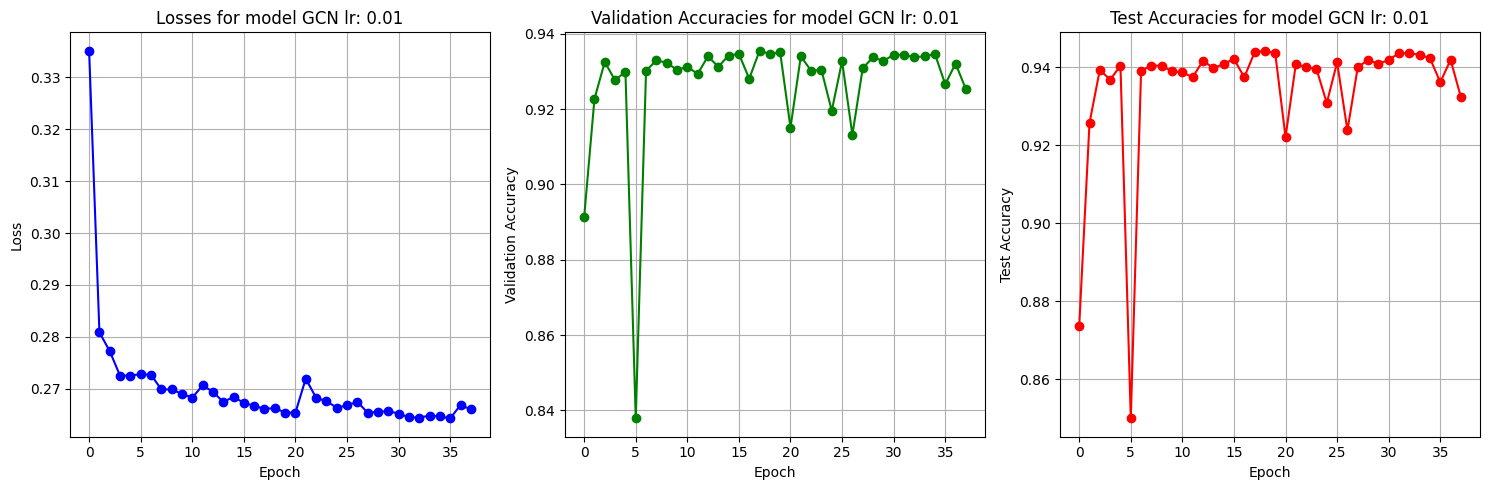

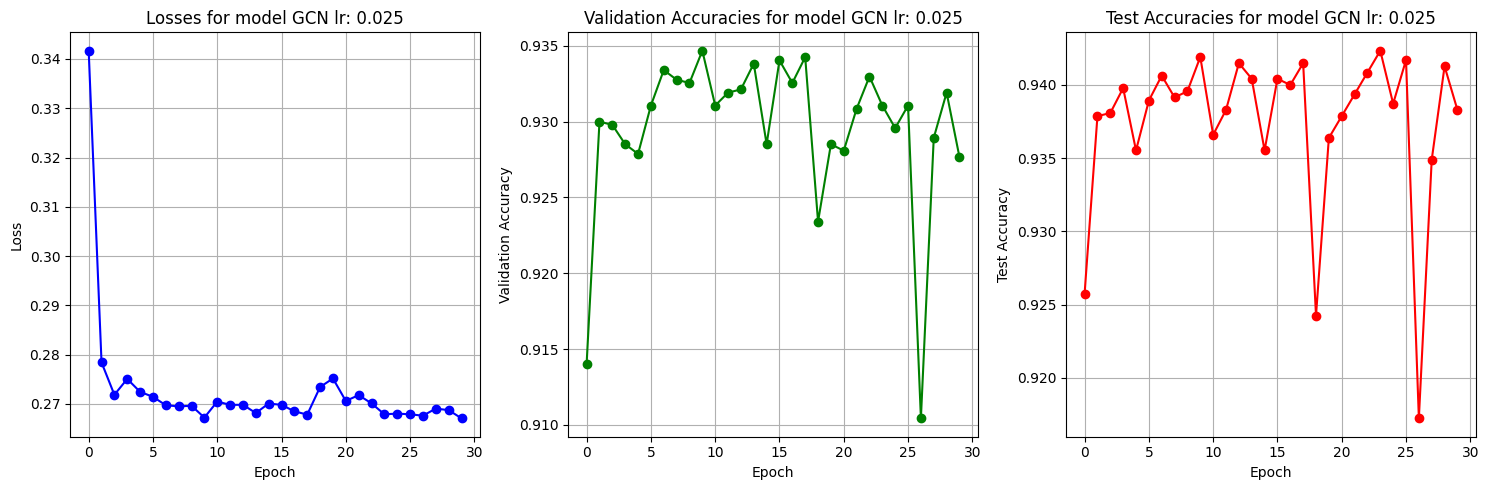

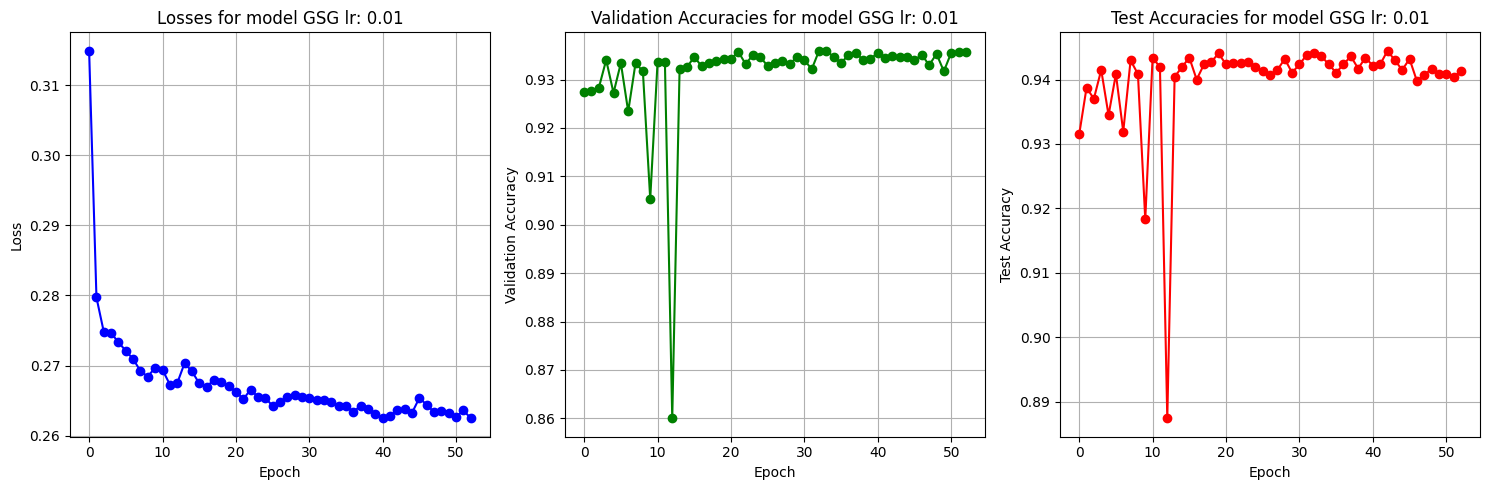

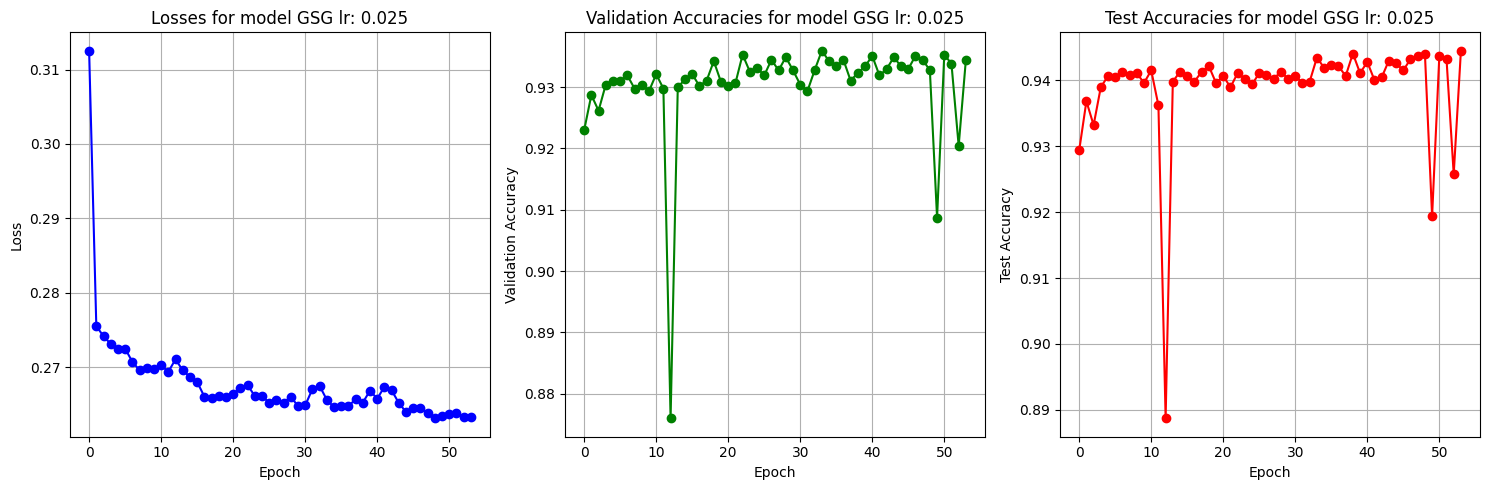

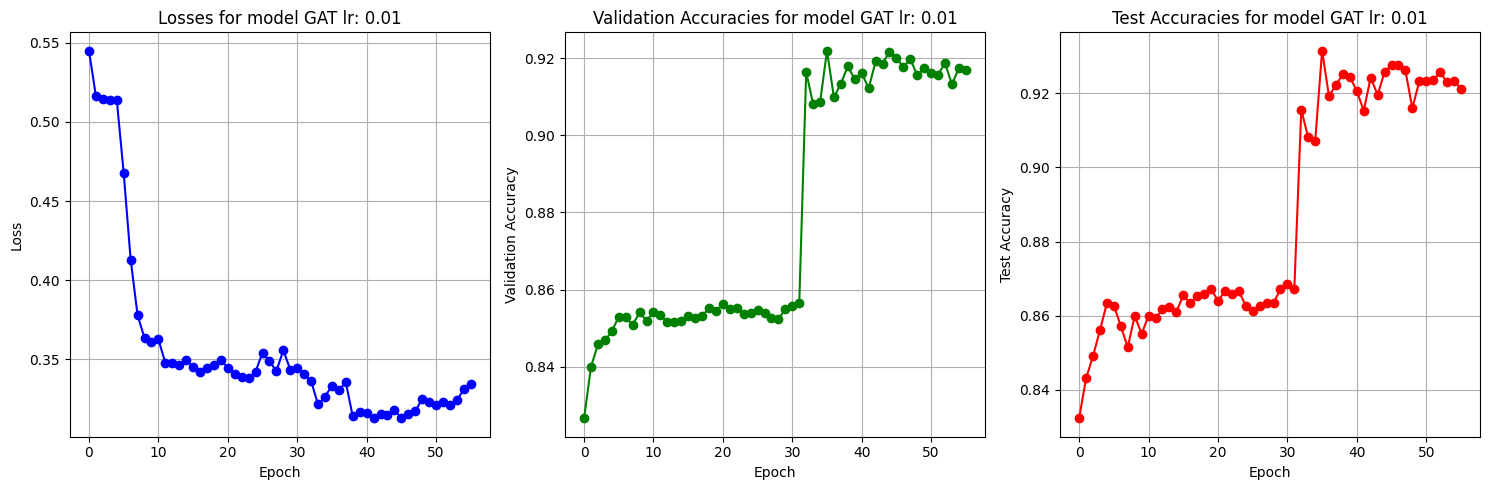

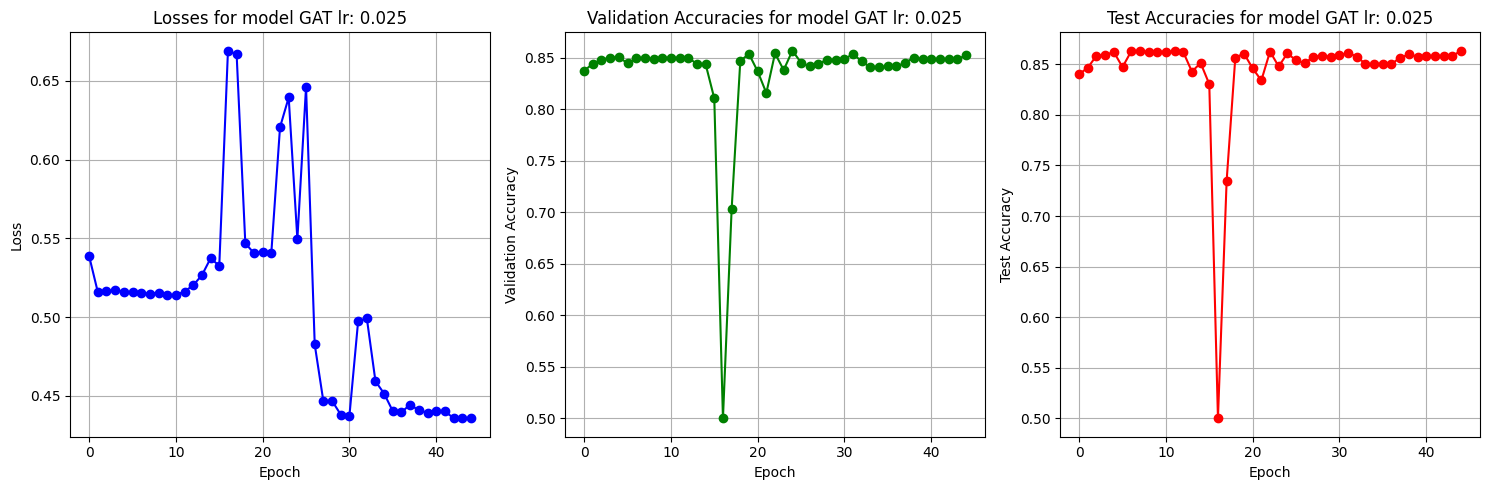

In [3]:
for key, val in model_res.items():
    gnn_utils.plot_metrics([f'{val["model"]} lr: {val["learning_rate"]}'], [val['losses']], [val['val_accs']], [val['test_accs']])    

### 3: Evaluating Trained Models on the Test Dataset

In this section, we show how to evaluate the performance of trained graph neural network (GNN) models stored in the `MODEL_PATH` directory. The evaluation is conducted on the test dataset to assess the generalization capability of each model.

1. **Loading Test Dataset**: The test dataset is loaded using the `get_ais_datasets` function as in the previous section. This third item in the tuple is the test-dataset which can be used to evaluate the models' classification performance.

2. **Model Evaluation**: All models saved as `.pt` files in the specified `MODEL_PATH` directory are loaded and evaluated using the `gnn_eval.test` function. Each model's test accuracy is computed, but the test function also returnes the saved array of losses, validation and test accuracies recorded during the training.

4. **Best Model Selection**: The model with the highest test accuracy is identified, and its performance is printed for reference.


In [ ]:
print(f'\nLoading test dataset from folder: {DATA_PATH}')
_, __, test_ds = gnn_utils.get_ais_datasets(DATA_PATH)    
print(f'\ntest dataset: {test_ds}')

model_files = glob.glob(os.path.join(MODEL_PATH, '*.pt'))

if len(model_files) == 0:
    raise ValueError(f'No .pt files found in folder: {MODEL_PATH}')
    
results = dict()
for model_file in model_files:
    model_type, learning_rate, test_acc, losses, val_accs, test_accs = gnn_eval.test('cpu', test_ds, model_file, batch_size=batch_size)
    results[model_file] = {'model': model_type, 'learning_rate': learning_rate, 'best_test_acc': test_acc, 'losses': losses, 'val_accs': val_accs, 'test_accs': test_accs}

best_model_file, best_model_data = max(results.items(), key=lambda item: item[1]['best_test_acc'])
print(f"\nBest Model: {best_model_data['model']}, learning rate: {best_model_data['learning_rate']}, results: {best_model_data['best_test_acc']}\n")


Loading test dataset from folder: ../data
create dgl dataset time: 6.01 seconds

test dataset: AISTimeseriesDataset(
  Number of graphs: 4700
  Node feature dimension: 3
  Number of label classes: 2
)


E:\Arbeid\ais_dgl\venv\Lib\site-packages\graph_classification\utils.py:59: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ..\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  res = torch.sparse.mm(d_mat_inv, adj)



Best Model: GSG, learning rate: 0.01, results: 0.9440425531914893

